In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# placeholder for data1 loading - fully preprocessed
data1 = pd.read_csv(r'data and feature eng\nasdaq_features_final.csv')
data2 = pd.read_csv(r'data and feature eng\nasdaq_features_final.csv')
data_final = pd.read_csv(r'data and feature eng\nasdaq_features_final.csv')

In [3]:
display(data1.head())
print(data1.shape)
print(data1.columns)

,Ticker,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY
0,AACG,1.277848,3.216686,0.397256,-0.965035,-0.158416,0.416667,0.041241
1,AAOI,0.483345,0.860750,0.561539,-0.984941,0.375373,3.081949,0.290901
2,AAXJ,0.056839,0.200890,0.282936,-0.445169,-0.002876,0.010610,0.727593
3,ACB,0.167617,1.015565,0.165048,-0.997938,0.011905,-0.311183,0.238018
4,ACIW,0.156537,0.345011,0.453718,-0.541763,-0.043839,0.079659,0.592863


(243, 8)
Index(['Ticker', 'Mean Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown',
       '30 Day Return', '90 Day Return', 'Correlation with SPY'],
      dtype='str')


In [4]:
data1.drop(columns=['Ticker'], inplace=True)  # not needed for clustering
data2.drop(columns=['Ticker'], inplace=True)  # not needed for clustering

In [5]:
scaler = StandardScaler()
df1_scaled = scaler.fit_transform(data1)
df1_scaled = pd.DataFrame(df1_scaled, columns=data1.columns)

df2_scaled = scaler.fit_transform(data2)
df2_scaled = pd.DataFrame(df2_scaled, columns=data2.columns)

pca_scaled = scaler.fit_transform(data1)
pca_scaled = pd.DataFrame(pca_scaled, columns=data1.columns)

df_final = scaler.fit_transform(data1)
df_final = pd.DataFrame(df_final, columns=data1.columns)

### PCA data

In [6]:
pca = PCA()
pca.fit(pca_scaled)
pca_samples = pca.transform(pca_scaled)

pcadf = pd.DataFrame(pca_samples)
pcadf.head()

,0,1,2,3,4,5,6
0,1.452616,-0.787430,-0.649473,1.235015,-0.514711,0.414796,0.021531
1,1.527877,-3.146216,3.275692,0.182335,-3.186166,0.974250,-0.010661
2,-1.214202,0.746551,0.094357,-1.417380,-0.008400,0.143997,0.010894
3,1.081506,-0.503120,-1.483655,0.045644,0.418495,-0.453437,-0.010289
4,-0.907783,0.559765,0.202256,-0.456745,-0.138389,0.039711,0.003152


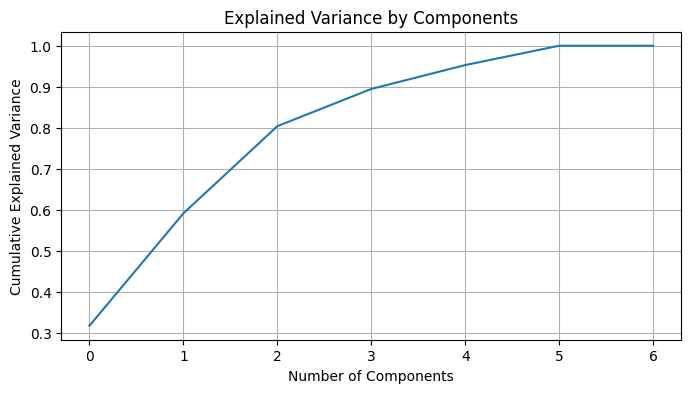

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.grid(True)
plt.show()

In [8]:
# https://github.com/bnsreenu/python_for_microscopists/blob/master/370_PCA_Dimensionality_Reduction.ipynb
# pca dim reduction

In [9]:
pca3 = PCA(n_components=3)
pca3.fit(pca_scaled)
pca_samples3 = pca3.transform(pca_scaled)

ps3 = pd.DataFrame(pca_samples3)
ps3.head()


,0,1,2
0,1.452616,-0.787430,-0.649473
1,1.527877,-3.146216,3.275692
2,-1.214202,0.746551,0.094357
3,1.081506,-0.503120,-1.483655
4,-0.907783,0.559765,0.202256


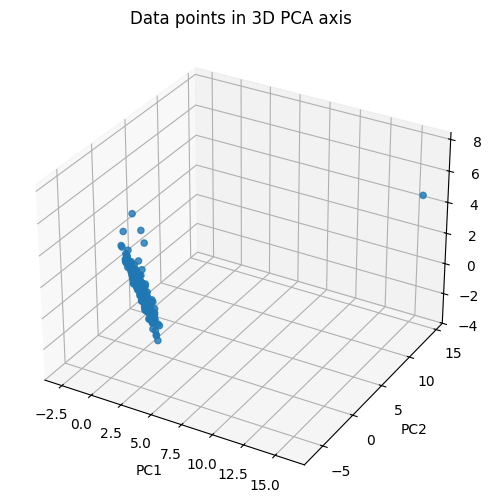

In [10]:
tocluster = pd.DataFrame(ps3[[0,1,2]])

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tocluster[0], tocluster[1], tocluster[2], s=20, c='C0', alpha=0.8)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Data points in 3D PCA axis')
plt.show()

In [11]:
# 2 dimensional PCA plot
pca2 = PCA(n_components=2)
pca2.fit(pca_scaled)
pca_samples2 = pca2.transform(pca_scaled)

ps2 = pd.DataFrame(pca_samples2)
ps2.head()

,0,1
0,1.452616,-0.787430
1,1.527877,-3.146216
2,-1.214202,0.746551
3,1.081506,-0.503120
4,-0.907783,0.559765


In [42]:
loadings = pd.DataFrame(
    pca2.components_.T,
    columns=['PC1', 'PC2'],
    index=pca_scaled.columns
) ** 2  # squared loadings for importance (for percentage)

# View absolute importance for the first principal component
print("1st Principal Component Loadings:")
print(loadings['PC1'].abs().sort_values(ascending=False))
print()

# View absolute importance for the second principal component
print("2nd Principal Component Loadings:")
print(loadings['PC2'].abs().sort_values(ascending=False))


1st Principal Component Loadings:
Volatility              0.221426
Mean Return             0.218523
Max Drawdown            0.215933
Correlation with SPY    0.209497
Sharpe Ratio            0.090194
30 Day Return           0.025574
90 Day Return           0.018853
Name: PC1, dtype: float64

2nd Principal Component Loadings:
Volatility              0.232453
Mean Return             0.232251
90 Day Return           0.174800
30 Day Return           0.140706
Max Drawdown            0.113869
Correlation with SPY    0.069210
Sharpe Ratio            0.036712
Name: PC2, dtype: float64


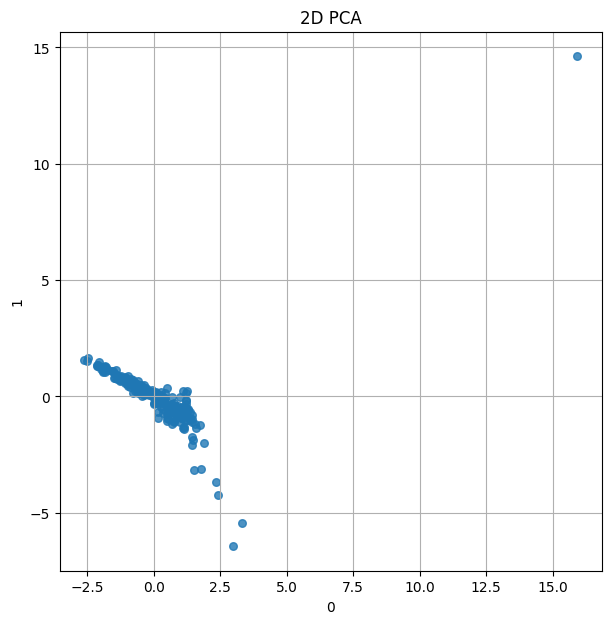

In [12]:
plt.figure(figsize=(7,7))
plt.scatter(ps2[0], ps2[1], s=30, c='C0', alpha=0.8)
plt.xlabel('0'); plt.ylabel('1')
plt.title('2D PCA')
plt.grid(True)
plt.show()

In [13]:
display(df1_scaled.head())
print(df1_scaled.shape)
print(df1_scaled.columns)

,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY
0,0.122449,0.083441,-0.085055,-1.107869,-0.541091,0.533323,-1.811321
1,-0.019515,-0.049812,0.561726,-1.193305,0.870171,5.590656,-0.585157
2,-0.095725,-0.087134,-0.535133,1.123341,-0.129866,-0.237163,1.559580
3,-0.075931,-0.041055,-0.999259,-1.249086,-0.090787,-0.847760,-0.844882
4,-0.077910,-0.078982,0.137234,0.708768,-0.238165,-0.106144,0.897879


(243, 7)
Index(['Mean Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown',
       '30 Day Return', '90 Day Return', 'Correlation with SPY'],
      dtype='str')


# K-Means

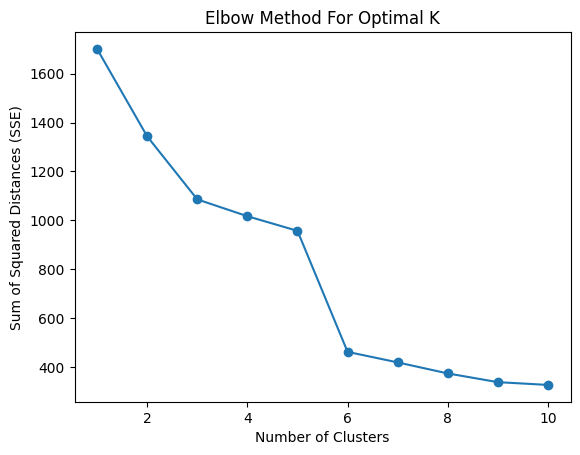

In [14]:
# elbow method for KMeans
X_original = df1_scaled[['Mean Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown',
           '30 Day Return', '90 Day Return', 'Correlation with SPY']]  # replace with actual feature names

# Elbow method to find optimal number of clusters
sse = []
k_range = range(1, 11)  # testing clusters from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_original)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

In [15]:
features = df1_scaled[['Mean Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown',
       '30 Day Return', '90 Day Return', 'Correlation with SPY']]

# Initialize KMeans with 3 clusters
kmeans_original = KMeans(n_clusters=6, random_state=42)

# Fit the model
df1_scaled['Cluster'] = kmeans_original.fit_predict(features)

# Rename clusters to numbers
cluster_mapping = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4', 4: 'Cluster 5', 5: 'Cluster 6'}
df1_scaled['Cluster'] = df1_scaled['Cluster'].map(cluster_mapping)

df1_scaled.head()

,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY,Cluster
0,0.122449,0.083441,-0.085055,-1.107869,-0.541091,0.533323,-1.811321,Cluster 3
1,-0.019515,-0.049812,0.561726,-1.193305,0.870171,5.590656,-0.585157,Cluster 1
2,-0.095725,-0.087134,-0.535133,1.123341,-0.129866,-0.237163,1.559580,Cluster 6
3,-0.075931,-0.041055,-0.999259,-1.249086,-0.090787,-0.847760,-0.844882,Cluster 3
4,-0.077910,-0.078982,0.137234,0.708768,-0.238165,-0.106144,0.897879,Cluster 6


# Kmeans with PCA data

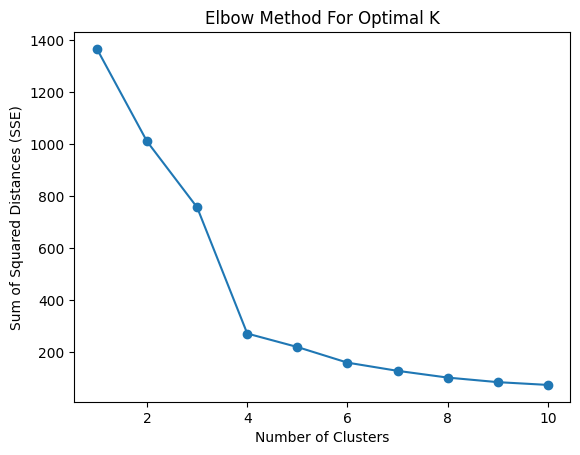

In [16]:
# 3 dimensional PCA data
# elbow method for KMeans
X_3 = ps3[[0,1,2]]  # replace with actual feature names

# Elbow method to find optimal number of clusters
sse = []
k_range = range(1, 11)  # testing clusters from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_3)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

In [17]:
features = ps3[[0,1,2]]

# Initialize KMeans with 3 clusters
kmeans_3 = KMeans(n_clusters=4, random_state=42)

# Fit the model
df1_scaled['Cluster'] = kmeans_3.fit_predict(features)

# Rename clusters to numbers
cluster_mapping = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4'}
df1_scaled['Cluster'] = df1_scaled['Cluster'].map(cluster_mapping)

df1_scaled.head()

,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY,Cluster
0,0.122449,0.083441,-0.085055,-1.107869,-0.541091,0.533323,-1.811321,Cluster 3
1,-0.019515,-0.049812,0.561726,-1.193305,0.870171,5.590656,-0.585157,Cluster 1
2,-0.095725,-0.087134,-0.535133,1.123341,-0.129866,-0.237163,1.559580,Cluster 2
3,-0.075931,-0.041055,-0.999259,-1.249086,-0.090787,-0.847760,-0.844882,Cluster 3
4,-0.077910,-0.078982,0.137234,0.708768,-0.238165,-0.106144,0.897879,Cluster 2


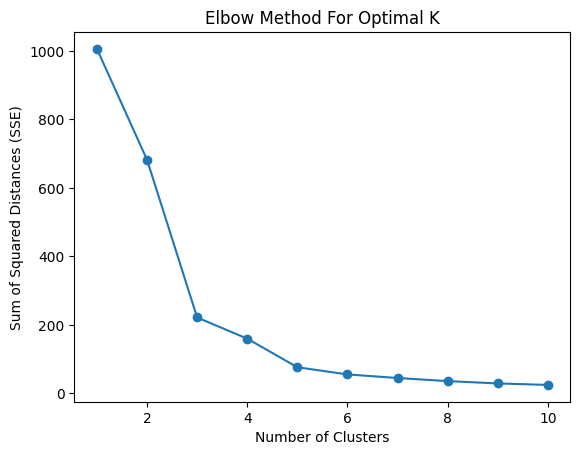

In [18]:
# 2 dimensional PCA data
# elbow method for KMeans
X_2 = ps2[[0,1]]  # replace with actual feature names

# Elbow method to find optimal number of clusters
sse = []
k_range = range(1, 11)  # testing clusters from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_2)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

In [19]:
features = ps2[[0,1]]

# Initialize KMeans with 5 clusters
kmeans_2 = KMeans(n_clusters=5, random_state=42)

# Fit the model
df_final['Cluster'] = kmeans_2.fit_predict(features)

# Rename clusters to numbers
cluster_mapping = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4', 4: 'Cluster 5'}
df_final['Cluster'] = df_final['Cluster'].map(cluster_mapping)

df_final.head()

,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY,Cluster
0,0.122449,0.083441,-0.085055,-1.107869,-0.541091,0.533323,-1.811321,Cluster 1
1,-0.019515,-0.049812,0.561726,-1.193305,0.870171,5.590656,-0.585157,Cluster 5
2,-0.095725,-0.087134,-0.535133,1.123341,-0.129866,-0.237163,1.559580,Cluster 2
3,-0.075931,-0.041055,-0.999259,-1.249086,-0.090787,-0.847760,-0.844882,Cluster 1
4,-0.077910,-0.078982,0.137234,0.708768,-0.238165,-0.106144,0.897879,Cluster 2


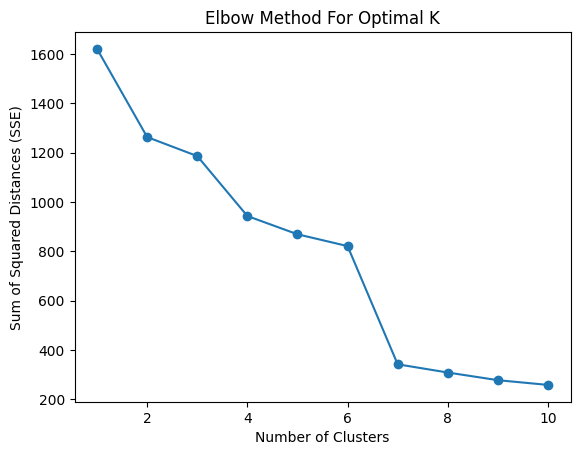

In [20]:
# 5 dimensional PCA data
# elbow method for KMeans
X_5 = pcadf[[0,1,2,3,4]]  # replace with actual feature names

# Elbow method to find optimal number of clusters
sse = []
k_range = range(1, 11)  # testing clusters from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_5)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

In [21]:
features = pcadf[[0,1,2,3,4]]

# Initialize KMeans with 7 clusters
kmeans_5 = KMeans(n_clusters=7, random_state=42)

# Fit the model
df1_scaled['Cluster'] = kmeans_5.fit_predict(features)

# Rename clusters to numbers
cluster_mapping = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4', 4: 'Cluster 5', 5: 'Cluster 6', 6: 'Cluster 7'}
df1_scaled['Cluster'] = df1_scaled['Cluster'].map(cluster_mapping)

df1_scaled.head()

,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY,Cluster
0,0.122449,0.083441,-0.085055,-1.107869,-0.541091,0.533323,-1.811321,Cluster 1
1,-0.019515,-0.049812,0.561726,-1.193305,0.870171,5.590656,-0.585157,Cluster 6
2,-0.095725,-0.087134,-0.535133,1.123341,-0.129866,-0.237163,1.559580,Cluster 2
3,-0.075931,-0.041055,-0.999259,-1.249086,-0.090787,-0.847760,-0.844882,Cluster 4
4,-0.077910,-0.078982,0.137234,0.708768,-0.238165,-0.106144,0.897879,Cluster 2


In [22]:
print(f"silhouette score for original data: {silhouette_score(X_original, kmeans.labels_)}\n"
      f"silhouette score for 3 dim pca: {silhouette_score(X_3, kmeans_3.labels_)}\n"
      f"silhouette score for 2 dim pca: {silhouette_score(X_2, kmeans_2.labels_)}\n"
      f"silhouette score for 5 dim pca: {silhouette_score(X_5, kmeans_5.labels_)}")

silhouette score for original data: 0.21245463228877096
silhouette score for 3 dim pca: 0.487947363216946
silhouette score for 2 dim pca: 0.49619967750272115
silhouette score for 5 dim pca: 0.2445566973501798


In [23]:
# best model with 5 clusters (dim 2)
Best_model = kmeans_2

# final data with cluster labels from df with 2 dim PCA cluster labels
labels = Best_model.labels_
labels = pd.Series(labels).map(cluster_mapping)
data_final['Cluster'] = labels
data_final['Cluster'].value_counts().sort_index()

Cluster
Cluster 1    87
Cluster 2    65
Cluster 3     1
Cluster 4    84
Cluster 5     6
Name: count, dtype: int64

In [24]:
# tickers for cluster 5
cluster_5_stocks = data_final[data_final['Cluster'] == 'Cluster 5']
print(cluster_5_stocks['Ticker'].tolist())

['AAOI', 'CNVS', 'INTZ', 'MESO', 'RCAT', 'VUZI']


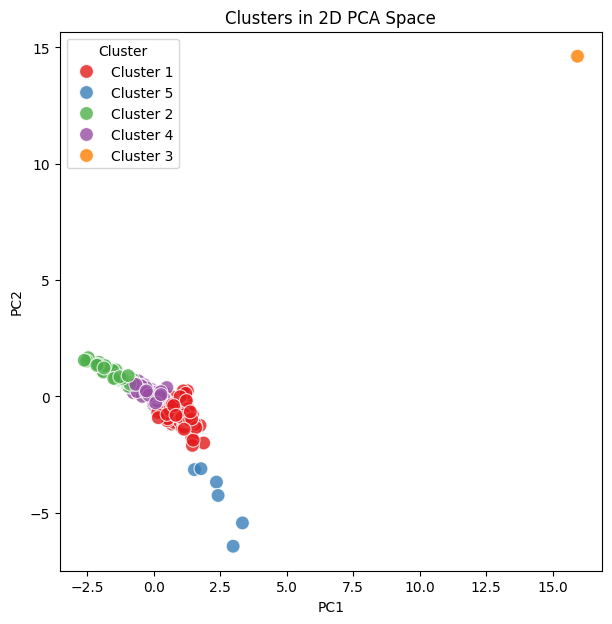

In [25]:
# plot of clusters in 2 dim PCA space
plt.figure(figsize=(7,7))
sns.scatterplot(x=ps2[0], y=ps2[1], hue=data_final['Cluster'], palette='Set1', s=100, alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters in 2D PCA Space')
plt.show()

# Recommendation Function

In [26]:
df_final.head()

,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY,Cluster
0,0.122449,0.083441,-0.085055,-1.107869,-0.541091,0.533323,-1.811321,Cluster 1
1,-0.019515,-0.049812,0.561726,-1.193305,0.870171,5.590656,-0.585157,Cluster 5
2,-0.095725,-0.087134,-0.535133,1.123341,-0.129866,-0.237163,1.559580,Cluster 2
3,-0.075931,-0.041055,-0.999259,-1.249086,-0.090787,-0.847760,-0.844882,Cluster 1
4,-0.077910,-0.078982,0.137234,0.708768,-0.238165,-0.106144,0.897879,Cluster 2


In [27]:
data_final.head()

,Ticker,Mean Return,Volatility,Sharpe Ratio,Max Drawdown,30 Day Return,90 Day Return,Correlation with SPY,Cluster
0,AACG,1.277848,3.216686,0.397256,-0.965035,-0.158416,0.416667,0.041241,Cluster 1
1,AAOI,0.483345,0.860750,0.561539,-0.984941,0.375373,3.081949,0.290901,Cluster 5
2,AAXJ,0.056839,0.200890,0.282936,-0.445169,-0.002876,0.010610,0.727593,Cluster 2
3,ACB,0.167617,1.015565,0.165048,-0.997938,0.011905,-0.311183,0.238018,Cluster 1
4,ACIW,0.156537,0.345011,0.453718,-0.541763,-0.043839,0.079659,0.592863,Cluster 2


In [28]:
import random

def recommend_stocks(stock_name: str, n_recs: int = 10):
    stock_name = stock_name.lower()
    # work on a copy so we don't mutate original
    df = df_final.copy()  

    # ensure we have a lowercase ticker column to search
    if 'Ticker' in df.columns:
        df['__ticker_search'] = df['Ticker'].astype(str).str.lower()
    else:
        df['__ticker_search'] = df.index.astype(str).str.lower()

    # find the stock
    mask = df['__ticker_search'].str.contains(stock_name, na=False)
    if not mask.any():
        return pd.DataFrame(columns=['Ticker', 'Cluster'])

    stock_row = df[mask].iloc[0]
    cluster = stock_row['Cluster']  # expects Cluster already present in data_final

    # all stocks in same cluster
    cluster_stocks = df[df['Cluster'] == cluster]

    # pick up to 10 examples (adjust as desired)
    n = min(n_recs, len(cluster_stocks))
    if n == 0:
        return pd.DataFrame(columns=['Ticker', 'Cluster'])

    sampled_idx = random.sample(list(cluster_stocks.index), n)
    recommended_rows = cluster_stocks.loc[sampled_idx]
    return recommended_rows[['Ticker', 'Cluster']].reset_index(drop=True)

In [43]:
s = input('Enter a stock name to get recommendations: ')

print('\n\n')
recommend_stocks(s)

,Ticker,Cluster


In [ ]:
data_final.to_csv("data and feature eng/clustered_stocks.csv", index=False)